In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torchvision.transforms import v2
from sklearn.model_selection import train_test_split

# 데이터 변환 정의
transform_train = v2.Compose([
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomResizedCrop(size=28),
    v2.RandomRotation(degrees=20),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize((0.5,), (0.5,))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# MNIST 데이터 로드
full_train_dataset = datasets.MNIST(root='./data', train=True, transform=transform_train, download=True)

# 데이터 나누기
train_indices, val_indices = train_test_split(range(len(full_train_dataset)), test_size=1/6, random_state=42)

# dataset 추가
train_dataset = torch.utils.data.Subset(full_train_dataset, train_indices)
val_dataset = torch.utils.data.Subset(full_train_dataset, val_indices)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform_test, download=True)

# DataLoader 설정
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# 데이터 크기 확인
print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

# GPU 사용 여부 확인
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

100%|██████████| 9.91M/9.91M [00:03<00:00, 3.27MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 182kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.45MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.54MB/s]

Train dataset size: 50000
Validation dataset size: 10000
Test dataset size: 10000
Using device: cpu


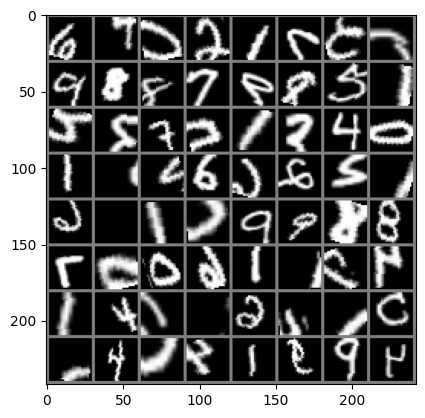

In [2]:
import torchvision
import matplotlib.pyplot as plt
import numpy as np

# 이미지 확인용
def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# 이미지 가져오기
dataiter = iter(train_loader)
images, labels = next(dataiter)

# 이미지 보여주기
imshow(torchvision.utils.make_grid(images))

In [3]:
from tqdm import tqdm

def train_model(model, train_loader, val_loader, optimizer, criterion, device, epochs, patience):
    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None
    train_losses = []
    val_losses = []

    # Training
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        correct = 0
        total = 0

        for images, labels in tqdm(train_loader):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss /= len(train_loader.dataset)
        train_acc = correct / total
        train_losses.append(train_loss)
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.4f}, Accuracy: {train_acc:.4f}")

       # Validation
        model.eval()
        val_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in tqdm(val_loader):
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                _, preds = torch.max(outputs, dim=1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_loss /= len(val_loader.dataset)
        val_acc = correct / total
        val_losses.append(val_loss)
        print(f"Validation Loss: {val_loss:.4f}, Accuracy: {val_acc:.4f}")

        torch.save(model.state_dict(), f'model_{epoch+1}.pth')

        # Early Stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_model_state = model.state_dict()
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                model.load_state_dict(best_model_state)
                break

    # Visualizing loss
    epochs_ran = len(val_losses)
    plt.plot(range(1, epochs_ran + 1), train_losses, label='Training Loss')
    plt.plot(range(1, epochs_ran + 1), val_losses, label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

In [4]:
def test_model(model, test_loader, criterion):
    model.eval()
    test_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in tqdm(test_loader):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    test_loss /= len(test_loader.dataset)
    test_acc = correct / total
    print(f"Test Loss: {test_loss:.4f}, Accuracy: {test_acc:.4f}")

In [5]:
import torch
import torch.nn as nn

class MyModel(nn.Module):
    def __init__(self):
        super(MyModel, self).__init__()
        self.conv1 = nn.Conv2d(1, 8, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.relu = nn.ReLU()
        self.fc1 = nn.Linear(32 * 3 * 3, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.pool(x)
        x = self.relu(self.conv2(x))
        x = self.pool(x)
        x = self.relu(self.conv3(x))
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# 모델 생성 및 디바이스 할당
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MyModel().to(device)

In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
epochs = 20
patience = 3

100%|██████████| 782/782 [01:38<00:00,  7.93it/s]


Epoch 1/20, Train Loss: 1.4733, Accuracy: 0.4921


100%|██████████| 157/157 [00:15<00:00,  9.87it/s]


Validation Loss: 1.1637, Accuracy: 0.6022


100%|██████████| 782/782 [01:07<00:00, 11.59it/s]


...

Validation Loss: 0.6253, Accuracy: 0.7881


100%|██████████| 782/782 [02:15<00:00,  5.76it/s]


Epoch 20/20, Train Loss: 0.6119, Accuracy: 0.7924


100%|██████████| 157/157 [00:28<00:00,  5.57it/s]


Validation Loss: 0.6008, Accuracy: 0.7954


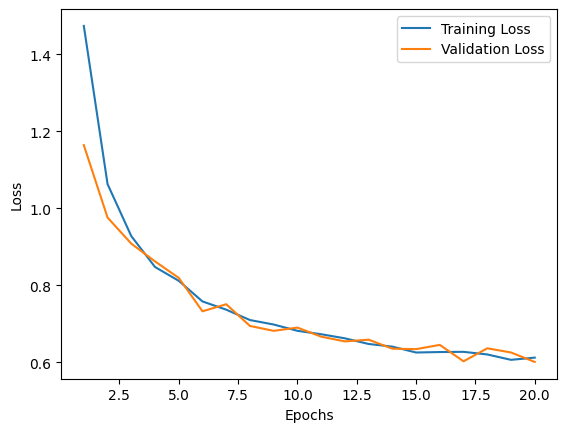

In [7]:
train_model(model, train_loader, val_loader, optimizer, criterion, device, epochs, patience)

In [8]:
test_model(model, test_loader, criterion)

100%|██████████| 157/157 [00:08<00:00, 18.55it/s]

Test Loss: 0.0818, Accuracy: 0.9732


In [9]:
# 가중치만 저장
torch.save(model.state_dict(), 'mnist_cnn_model.pth')

# 전체 모델 저장
torch.save(model, 'mnist_cnn_full.pth')

In [10]:
from copy import deepcopy
import torch.quantization
from torch.ao.quantization import QConfig, default_observer, default_weight_observer

# 1.bf16 타입으로의 변경
model_bf16 = deepcopy(model)
model_bf16 = model_bf16.to(torch.bfloat16)
torch.save(model_bf16.state_dict(), 'mnist_cnn_bf16_quantized.pth')

# 2.동적양자화 ptq
quantized_model = torch.quantization.quantize_dynamic(
    model,
    {nn.Linear},  # 양자화할 레이어 (Fully Connected 레이어 대상)
    dtype=torch.qint8  # INT8로 양자화
)

torch.save(quantized_model, 'mnist_cnn_dynamic_quantized.pth')

# 3.정적양자화
model_static_quantized = deepcopy(model)
model_static_quantized.eval()

qconfig = QConfig(
    activation=default_observer,
    weight=default_weight_observer
)
model_static_quantized.qconfig = qconfig

model_static_quantized = torch.quantization.prepare(model_static_quantized, inplace=False)

dummy_input = torch.randn(1, 1, 28, 28).to(device)
model_static_quantized(dummy_input)

model_static_quantized = torch.quantization.convert(model_static_quantized, inplace=False)
torch.save(model_static_quantized, 'mnist_cnn_static_quantized.pth')

In [11]:
import os

for f in os.listdir("."):
    if os.path.isfile(f):
        size_mb = os.path.getsize(f) / (1024 * 1024)
        print(f"{f}: {size_mb:.2f} MB")

inference.ipynb: 0.06 MB
mnist_cnn_bf16_quantized.pth: 0.09 MB
mnist_cnn_dynamic_quantized.pth: 0.07 MB
mnist_cnn_full.pth: 0.17 MB
mnist_cnn_model.pth: 0.17 MB
mnist_cnn_static_quantized.pth: 0.05 MB
modeling.ipynb: 0.16 MB
README.md: 0.00 MB


In [12]:
%pip install onnx onnxruntime

   ---------------------------------------- 0.0/15.9 MB ? eta -:--:--
   --------- ------------------------------ 3.7/15.9 MB 18.1 MB/s eta 0:00:01
   -------------------- ------------------- 8.1/15.9 MB 19.4 MB/s eta 0:00:01
   --------------------------------- ------ 13.4/15.9 MB 20.4 MB/s eta 0:00:01
   ---------------------------------------- 15.9/15.9 MB 18.5 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [13]:
model.eval()
dummy_input = torch.randn(1, 1, 28, 28).to(device)  # MNIST 입력 크기
onnx_path = 'mnist_cnn.onnx'

torch.onnx.export(
    model,                     # 내보낼 모델
    dummy_input,               # 더미 입력
    onnx_path,                 # 저장할 파일 이름
    verbose=True,              # 변환 과정 로그 출력
    input_names=["input"],     # 입력 레이어 이름
    output_names=["output"],   # 출력 레이어 이름
    opset_version=11           # ONNX 연산자 세트 버전
)
print(f"Model saved to '{onnx_path}'.")

Model saved to 'mnist_cnn.onnx'.


In [ ]:
import torch
import torch.nn.utils.prune as prune

model_path = "/content/mnist_cnn_full.pth"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = torch.load(model_path, map_location=device, weights_only=False)

modules_to_prune = [
    (model.conv1, 'weight'),
    (model.conv2, 'weight'),
    (model.conv3, 'weight'),
    (model.fc1, 'weight'),
    (model.fc2, 'weight')
]

prune.global_unstructured(
    modules_to_prune,
    pruning_method=prune.L1Unstructured,
    amount=0.2,
)

for module, name in modules_to_prune:
    prune.remove(module, name)
    print(f"Pruned {name} in {module}")

model_pruned_path = "/content/mnist_cnn_pruned.pth"
torch.save(model, model_pruned_path)